# 🛰️ HyWAP — Preprocessing (PRISMA HDF5 → clipped ENVI cube + panchromatic)
### Step 0 of the pipeline · run once

This notebook does the heavy part **once**: it converts the raw **PRISMA L2D** product (`.he5`) to an **ENVI reflectance cube** + **panchromatic** band with [hylite](https://github.com/samthiele/hylite), then **clips both to the study area** and saves small files. The analysis notebook (`HyWAP_PoC.ipynb`) starts from these clips, so it never loads the full scene. 🪶

> ⚠️ **You only need this notebook if you have the raw PRISMA L2D `.he5` file.**
> If you received the **clips** we share — `Prisma_LGHARB_test` (+ its `.hdr`) and `PRISMA_Pan_test.tif` — **skip this notebook** and go straight to `HyWAP_PoC.ipynb`: the clips are its direct inputs. ✅

> ℹ️ PRISMA **L2D is already a surface-reflectance product** — **no atmospheric correction** is applied here. We only do format conversion, VNIR/SWIR merge, band-validity filtering and wavelength sorting.

_Conversion follows the hylite PRISMA tutorial (Sam Thiele, GFZ)._

## 📦 0. Install
💡 Locally, everything is already in the **`hywap.yml`** conda environment:
```bash
conda env create -f hywap.yml && conda activate hywap
```
On **Google Colab**, uncomment the `pip` line in the next cell.

In [ ]:
# Local: already provided by hywap.yml. Google Colab: uncomment the line below to install.
#!pip install -q git+https://github.com/samthiele/hylite.git h5py rasterio geopandas shapely
import h5py, hylite, rasterio, geopandas            # sanity check
from IPython.display import clear_output; clear_output()
print("Dependencies ready.")

## ☁️ Google Drive (Colab only)
On Colab this mounts your Drive. On a **local machine it does nothing** — just set local paths in the next cell.

In [ ]:
try:
    from google.colab import drive; drive.mount("/content/drive")
except Exception:
    print("Not on Colab — using local paths.")

## 📁 1. Paths
Set the input (`.he5`) and the study area. The **output names are the exact inputs of `HyWAP_PoC.ipynb`** — keep them as-is.

In [1]:
import os, numpy as np

# --- INPUT: raw PRISMA L2D product (.he5) ---
WORKDIR   = "D:\work\Hackathon\Inputs"                                   # local working directory
HDF5_PATH = os.path.join(WORKDIR, "PRS_L2D_STD_20210324111709_20210324111714_0001.he5")

# --- study area to clip to: a shapefile/GeoPackage, OR a lon/lat bounding box ---
AOI_MODE  = "shapefile"                           # "shapefile" or "bbox"
AOI_SHP   = os.path.join(WORKDIR, "Study_area.gpkg")   # used if AOI_MODE == "shapefile"
AOI_BBOX  = (-6.80, 32.40, -6.55, 32.60)          # (lon_min, lat_min, lon_max, lat_max) if AOI_MODE == "bbox"

# --- OUTPUT: clips consumed directly by HyWAP_PoC.ipynb (keep these exact names) ---
CLIP_CUBE = os.path.join(WORKDIR, "Prisma_LGHARB_test")    # ENVI cube (+ .hdr with wavelengths)
CLIP_PAN  = os.path.join(WORKDIR, "PRISMA_Pan_test.tif")   # GeoTIFF panchromatic
print("paths set")

paths set


## 🔄 2. Convert the full scene with hylite (HDF5 → cube + PAN)
Read the VNIR + SWIR cubes and the 5 m panchromatic, merge VNIR/SWIR, keep only valid bands and sort them by wavelength.

In [2]:
import h5py, hylite, hylite.io as hio
f = h5py.File(HDF5_PATH, "r")
easting  = float(f.attrs["Product_ULcorner_easting"])
northing = float(f.attrs["Product_ULcorner_northing"])
epsg = "EPSG:%d" % int(f.attrs["Epsg_Code"])
wl_VNIR = np.flipud(f.attrs["List_Cw_Vnir"]); wl_SWIR = np.flipud(f.attrs["List_Cw_Swir"])
VNIR_valid = np.argwhere(wl_VNIR > 0.)[:,0]
SWIR_valid = np.argwhere((wl_SWIR > 0.) * (wl_SWIR > np.amax(wl_VNIR)))[:,0]
wl = np.hstack((wl_VNIR[VNIR_valid], wl_SWIR[SWIR_valid]))
V = f["/HDFEOS/SWATHS/PRS_L2D_HCO/Data Fields/VNIR_Cube"][:,:,:]
S = f["/HDFEOS/SWATHS/PRS_L2D_HCO/Data Fields/SWIR_Cube"][:,:,:]
V = np.transpose(V, (2,0,1))[...,::-1][..., VNIR_valid]
S = np.transpose(S, (2,0,1))[...,::-1][..., SWIR_valid]
HSI = np.dstack((V, S)).astype("float32")
PAN = np.transpose(f["/HDFEOS/SWATHS/PRS_L2D_PCO/Data Fields/Cube"][:,:]).astype("float32")
f.close()
print("Full scene:", HSI.shape, "| PAN", PAN.shape, "|", epsg)

Full scene: (1181, 1178, 230) | PAN (7086, 7068) | EPSG:32629


## ✂️ 3. Clip to the study area & save the light clips
We save the full scene, then clip with `rasterio.mask` (georeferenced → correct zone & north-up). The **cube stays ENVI** (wavelengths in its `.hdr`); the **panchromatic is written as GeoTIFF**.

In [4]:
import geopandas as gpd, rasterio
from rasterio.mask import mask as rmask
from shapely.geometry import box

# study-area polygon in the cube CRS
if AOI_MODE == "shapefile":
    aoi = gpd.read_file(AOI_SHP).to_crs(epsg)
else:
    aoi = gpd.GeoDataFrame({"geometry":[box(*AOI_BBOX)]}, crs="EPSG:4326").to_crs(epsg)

# 1) save the FULL scene (hylite -> ENVI, keeps georef + wavelength header)
FULL_CUBE = os.path.join(WORKDIR, "_full_hsi"); FULL_PAN = os.path.join(WORKDIR, "_full_pan")
im = hio.HyImage(HSI); im.set_wavelengths(wl); im.set_projection_EPSG(epsg)
im.affine = [easting, 30., 0, northing, 0., -30.]
hio.saveWithGDAL(FULL_CUBE, im)
pim = hio.HyImage(PAN[:, :, None]); pim.set_projection_EPSG(epsg)
pim.affine = [easting, 5., 0, northing, 0., -5.]
hio.saveWithGDAL(FULL_PAN, pim)

# 2) clip (crop to the AOI) and write each output with the right driver
def clip_to(src_path, dst_path, driver):
    with rasterio.open(src_path) as s:
        arr, tr = rmask(s, aoi.geometry, crop=True)
        prof = {"driver":driver, "height":arr.shape[1], "width":arr.shape[2],
                "count":s.count, "dtype":arr.dtype, "crs":s.crs,
                "transform":tr, "nodata":s.nodata}
        with rasterio.open(dst_path, "w", **prof) as d: d.write(arr)
    return arr.shape
cshape = clip_to(FULL_CUBE, CLIP_CUBE, "ENVI")     # cube -> ENVI (+ .hdr)
pshape = clip_to(FULL_PAN,  CLIP_PAN,  "GTiff")    # pan  -> GeoTIFF (.tif)

# 3) copy the wavelengths into the clipped cube .hdr (so HyWAP_PoC.ipynb can read them)
hdr = CLIP_CUBE + ".hdr"; txt = open(hdr).read()
if "wavelength" not in txt.lower():
    wls = ",".join(f"{w:.3f}" for w in wl)
    open(hdr, "a").write(f"\nwavelength = {{{wls}}}\n")

aoi.to_file(os.path.join(WORKDIR, "study_area_boundary.gpkg"), driver="GPKG")
print("Saved clips:")
print("  cube ->", CLIP_CUBE, cshape, "(ENVI + .hdr)")
print("  pan  ->", CLIP_PAN,  pshape, "(GeoTIFF)")
print("  boundary -> study_area_boundary.gpkg")
print("These are the exact inputs of HyWAP_PoC.ipynb (CLIP_CUBE / CLIP_PAN).")

Saved clips:
  cube -> D:\work\Hackathon\Inputs\Prisma_LGHARB_test (230, 118, 165) (ENVI + .hdr)
  pan  -> D:\work\Hackathon\Inputs\PRISMA_Pan_test.tif (1, 708, 985) (GeoTIFF)
  boundary -> study_area_boundary.gpkg
These are the exact inputs of HyWAP_PoC.ipynb (CLIP_CUBE / CLIP_PAN).


## 👁️ 4. Quick check
RGB from the clipped cube + the clipped panchromatic, to confirm the zone and orientation are right.

clip cube: 230 bands 118 x 165 | EPSG:32629


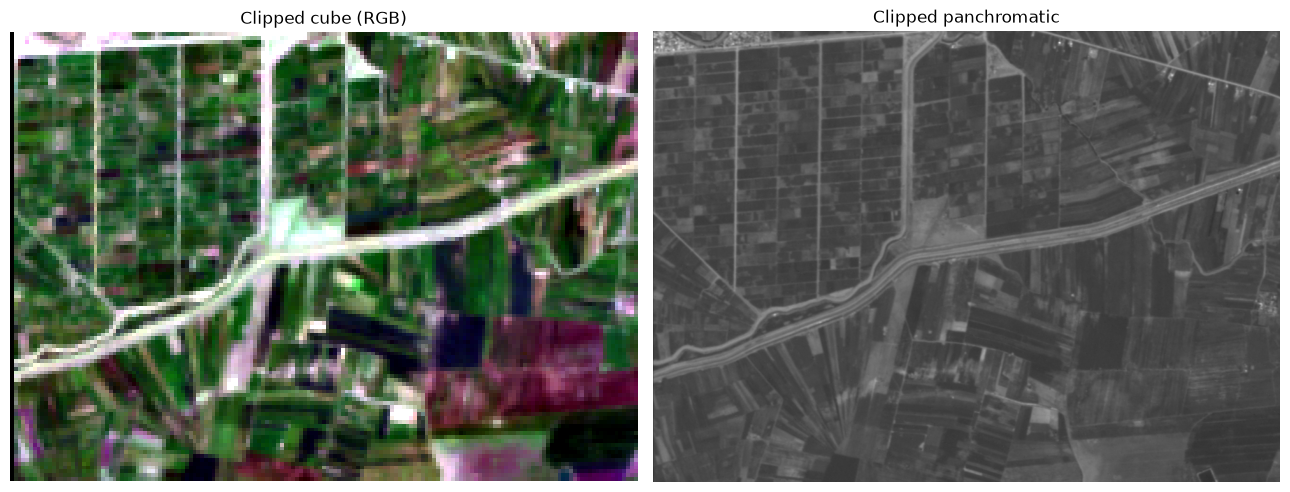

In [5]:
import rasterio, numpy as np, matplotlib.pyplot as plt
with rasterio.open(CLIP_CUBE) as s:
    print("clip cube:", s.count, "bands", s.height, "x", s.width, "|", s.crs)
    def b(i): return s.read(i).astype("float32")
    def q(a):
        lo,hi=np.nanpercentile(a,(2,98)); return np.clip((a-lo)/(hi-lo+1e-9),0,1)
    rgb=np.dstack([q(b(32)),q(b(20)),q(b(10))])
with rasterio.open(CLIP_PAN) as p: pan=p.read(1)
fig,ax=plt.subplots(1,2,figsize=(13,6))
ax[0].imshow(rgb); ax[0].set_title("Clipped cube (RGB)"); ax[0].axis("off")
ax[1].imshow(pan,cmap="gray"); ax[1].set_title("Clipped panchromatic"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## 📤 Data access & reproducibility

🔒 **PRISMA data licensing.** In line with the PRISMA (ASI) data policy, the raw scene is **not redistributed** in this repository.

**▶️ Option A — reproduce from the full scene.**
If you want the whole scene, please **download the PRISMA L2D product** from the official portal — [prisma.asi.it](https://prisma.asi.it) (free registration required).
Scene used here: `PRS_L2D_STD_20210324111709_..._0001` — Gharb plain, Morocco, 2021-03-24.
Then run `HyWAP_preprocessing.ipynb` (→ generates the clips), followed by `HyWAP_PoC.ipynb` (→ the full analysis).

**▶️ Option B — run directly on the provided test data (quickest).**
Otherwise, just work with the **test clips** we provide: drop these three files next to `HyWAP_PoC.ipynb` and run it top to bottom — **no HDF5, no hylite needed** ✅:

- `Prisma_LGHARB_test`  +  `Prisma_LGHARB_test.hdr`  — clipped hyperspectral cube (ENVI)
- `PRISMA_Pan_test.tif`  — clipped 5 m panchromatic (GeoTIFF)
- `study_area_boundary.gpkg`  — study-area outline